# v6 — two run frames: all normal vs 50-per-IDV faulty

`te_process.csv` is 15.3M rows. This notebook keeps two tables, then scores every run.

| frame | what | runs | rows |
|---|---|---|---|
| **`df1`** | every `fault_status == "normal"` run (IDV 0, train + test) | 1,000 | **730,000** |
| **`df2`** | random **test** faulty runs, **50 per `faultNumber` 1–20** | 1,000 | **960,000** |

Row counts are exact: train-normal is 500 runs × 500 samples, test-normal is 500 × 960, test-faulty is 50 × 20 × 960. The raw CSV has **57** columns (5 meta + 41 `xmeas_*` + 11 `xmv_*`). Cached after the first 15M-row scan.

**Detectors** (no CSV labels when deciding): `v5_combined` (moments ∪ freeze ∪ amplitude), plus rolling `zscore_4sd_self` and `persist_4sd_self`. A run is predicted faulty if it has **any** yellow or red sample; otherwise normal. TPR/FPR vs `fault_status`.


In [28]:
from __future__ import annotations

import logging
import time
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

pd.set_option("display.max_columns", 20)
pd.set_option("display.width", 160)

log = logging.getLogger("v6_frames")
if not log.handlers:
    handler = logging.StreamHandler()
    handler.setFormatter(logging.Formatter("%(asctime)s  %(levelname)-7s  %(message)s", datefmt="%H:%M:%S"))
    log.addHandler(handler)
    log.setLevel(logging.INFO)
    log.propagate = False

CSV_PATH = Path("te_process.csv")
CATALOG_PATH = Path("run_moments_s1_500.csv")
CACHE_NORMAL = Path("v6_df1_normal_1000runs.csv")
CACHE_FAULTY = Path("v6_df2_faulty_50per_idv.csv")
CHUNKSIZE = 250_000
META_COLS = ["faultNumber", "simulationRun", "sample", "source", "fault_status"]

TRAIN_SAMPLES = 500
TEST_SAMPLES = 960
N_FAULTY_PER_IDV = 50
FAULT_NUMBERS = tuple(range(1, 21))
FAULTY_SOURCE = "test"
SPLIT_SEED = 42

log.info("csv         %s", CSV_PATH.resolve())
log.info("exists      %s", CSV_PATH.exists())
log.info("df1         all normal runs (train 1–%s + test 1–%s)", TRAIN_SAMPLES, TEST_SAMPLES)
log.info("df2         %s %s runs / IDV  %s  seed=%s", N_FAULTY_PER_IDV, FAULTY_SOURCE, list(FAULT_NUMBERS), SPLIT_SEED)


19:48:34  INFO     csv         /Users/ob/Projects/hackathon_csv/data_processing/te_process.csv
19:48:34  INFO     exists      True
19:48:34  INFO     df1         all normal runs (train 1–500 + test 1–960)
19:48:34  INFO     df2         50 test runs / IDV  [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20]  seed=42


## 1. Draw 50 test runs per IDV, then stream both frames

`df1` is every IDV(0) trajectory. `df2` keys are shuffled **inside each** `faultNumber` (seed 42), 50 test `simulationRun` values, all 20 IDVs. One CSV pass fills both; later cells load the caches.


In [29]:
def sensor_columns(columns) -> list[str]:
    return [c for c in columns if str(c).startswith("xmeas_") or str(c).startswith("xmv_")]


def compact_frame(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    if "faultNumber" in out.columns:
        out["faultNumber"] = out["faultNumber"].astype(np.int16)
    if "simulationRun" in out.columns:
        out["simulationRun"] = out["simulationRun"].astype(np.int16)
    if "sample" in out.columns:
        out["sample"] = out["sample"].astype(np.int16)
    if "source" in out.columns:
        out["source"] = out["source"].astype("category")
    if "fault_status" in out.columns:
        out["fault_status"] = out["fault_status"].astype("category")
    for c in sensor_columns(out.columns):
        out[c] = pd.to_numeric(out[c], downcast="float")
    return out


def native_len(source) -> int:
    return TEST_SAMPLES if str(source) == "test" else TRAIN_SAMPLES


def in_native_window(df: pd.DataFrame) -> pd.Series:
    sample = df["sample"].astype(int)
    cap = np.where(df["source"].astype(str).eq("test"), TEST_SAMPLES, TRAIN_SAMPLES)
    return sample.ge(1) & sample.le(cap)


def load_run_catalog() -> pd.DataFrame:
    if CATALOG_PATH.exists():
        cat = pd.read_csv(CATALOG_PATH, usecols=["source", "faultNumber", "simulationRun", "fault_status"])
        log.info("catalog     %s  runs=%s", CATALOG_PATH.name, f"{len(cat):,}")
        return compact_frame(cat)
    keys = []
    header = pd.read_csv(CSV_PATH, nrows=0)
    usecols = [c for c in META_COLS if c in header.columns]
    for chunk in pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE):
        live = compact_frame(chunk.loc[in_native_window(chunk)])
        keys.append(live[META_COLS].drop_duplicates())
    cat = pd.concat(keys, ignore_index=True).drop_duplicates()
    log.info("catalog     streamed  runs=%s", f"{len(cat):,}")
    return cat


def draw_faulty_keys(n_per_idv: int = N_FAULTY_PER_IDV, seed: int = SPLIT_SEED) -> pd.DataFrame:
    cat = load_run_catalog()
    pool = cat.loc[
        cat["source"].astype(str).eq(FAULTY_SOURCE)
        & cat["faultNumber"].astype(int).isin(FAULT_NUMBERS)
    ].copy()
    rng = np.random.default_rng(seed)
    parts: list[pd.DataFrame] = []
    for fault in FAULT_NUMBERS:
        block = pool.loc[pool["faultNumber"].astype(int).eq(fault)]
        if len(block) < n_per_idv:
            raise RuntimeError(f"IDV({fault}) has {len(block)} {FAULTY_SOURCE} runs, need {n_per_idv}")
        idx = rng.choice(len(block), size=n_per_idv, replace=False)
        parts.append(block.iloc[idx])
    keys = pd.concat(parts, ignore_index=True)
    return keys.sort_values(["faultNumber", "simulationRun"]).reset_index(drop=True)


def _as_key_df(keys: pd.DataFrame) -> pd.DataFrame:
    return (
        keys[["source", "faultNumber", "simulationRun"]]
        .drop_duplicates()
        .assign(
            source=lambda d: d["source"].astype(str),
            faultNumber=lambda d: d["faultNumber"].astype(int),
            simulationRun=lambda d: d["simulationRun"].astype(int),
        )
    )


def stream_frames(faulty_keys: pd.DataFrame) -> tuple[pd.DataFrame, pd.DataFrame]:
    key_df = _as_key_df(faulty_keys)
    keyset = set(zip(key_df["source"], key_df["faultNumber"], key_df["simulationRun"]))
    header = pd.read_csv(CSV_PATH, nrows=0)
    sensors = sensor_columns(header.columns)
    usecols = [c for c in META_COLS + sensors if c in header.columns]

    normal_parts: list[pd.DataFrame] = []
    faulty_parts: list[pd.DataFrame] = []
    n_normal = 0
    n_seen = 0
    counts: dict[tuple, int] = {}
    t0 = time.time()

    for i, chunk in enumerate(pd.read_csv(CSV_PATH, usecols=usecols, chunksize=CHUNKSIZE), start=1):
        n_seen += len(chunk)
        live = compact_frame(chunk.loc[in_native_window(chunk)])
        if live.empty:
            continue

        normal = live.loc[live["fault_status"].astype(str).eq("normal")]
        if len(normal):
            normal_parts.append(normal)
            n_normal += len(normal)

        sub = live.merge(key_df, on=["source", "faultNumber", "simulationRun"], how="inner")
        if len(sub):
            faulty_parts.append(sub)
            for key, n_rows in sub.groupby(["source", "faultNumber", "simulationRun"], sort=False).size().items():
                k = (str(key[0]), int(key[1]), int(key[2]))
                counts[k] = counts.get(k, 0) + int(n_rows)

        have = set(counts)
        if i == 1 or i % 8 == 0:
            log.info(
                "stream      chunk %s  scanned=%s  normal=%s  faulty_keys=%s/%s  %.1fs",
                i, f"{n_seen:,}", f"{n_normal:,}", len(have), len(keyset), time.time() - t0,
            )
        if n_normal >= 730_000 and have >= keyset and all(counts.get(k, 0) >= native_len(k[0]) for k in keyset):
            log.info("stream      complete at chunk %s  %.1fs", i, time.time() - t0)
            break

    if not normal_parts:
        raise RuntimeError(f"no normal rows in {CSV_PATH}")
    if not faulty_parts:
        raise RuntimeError("no selected faulty runs found")

    df1 = (
        pd.concat(normal_parts, ignore_index=True)
        .sort_values(["source", "simulationRun", "sample"], kind="mergesort")
        .reset_index(drop=True)
    )
    df2 = (
        pd.concat(faulty_parts, ignore_index=True)
        .sort_values(["faultNumber", "simulationRun", "sample"], kind="mergesort")
        .reset_index(drop=True)
    )
    log.info("stream done  scanned=%s  df1=%s  df2=%s  %.1fs", f"{n_seen:,}", df1.shape, df2.shape, time.time() - t0)
    return df1, df2


def load_or_build_frames() -> tuple[pd.DataFrame, pd.DataFrame]:
    if CACHE_NORMAL.exists() and CACHE_FAULTY.exists():
        df1 = compact_frame(pd.read_csv(CACHE_NORMAL))
        df2 = compact_frame(pd.read_csv(CACHE_FAULTY))
        log.info("cache hit   %s  %s", CACHE_NORMAL.name, df1.shape)
        log.info("cache hit   %s  %s", CACHE_FAULTY.name, df2.shape)
        return df1, df2

    keys = draw_faulty_keys()
    log.info("faulty keys %s  (%s per IDV)", len(keys), N_FAULTY_PER_IDV)
    display(keys.head(20))
    df1, df2 = stream_frames(keys)
    df1.to_csv(CACHE_NORMAL, index=False)
    df2.to_csv(CACHE_FAULTY, index=False)
    log.info("cache write %s  %s", CACHE_NORMAL.name, df1.shape)
    log.info("cache write %s  %s", CACHE_FAULTY.name, df2.shape)
    return df1, df2


df1, df2 = load_or_build_frames()
FEATURE_COLS = sensor_columns(df1.columns)
log.info("sensors     %s  columns=%s", len(FEATURE_COLS), df1.shape[1])


19:48:37  INFO     cache hit   v6_df1_normal_1000runs.csv  (730000, 57)
19:48:37  INFO     cache hit   v6_df2_faulty_50per_idv.csv  (960000, 57)
19:48:37  INFO     sensors     52  columns=57


## 2. Check shapes, run counts, and the 50-per-IDV split

Expect `df1.shape == (730000, 57)` and `df2.shape == (960000, 57)`: 1,000 normal runs, 1,000 faulty runs, 50 test runs on every `faultNumber`.


In [30]:
def run_count(df: pd.DataFrame) -> int:
    return df.groupby(["source", "faultNumber", "simulationRun"], observed=True).ngroups


def summarize(df: pd.DataFrame) -> pd.DataFrame:
    return (
        df.groupby(["source", "faultNumber"], sort=True, observed=True)
        .agg(
            n=("sample", "size"),
            runs=("simulationRun", "nunique"),
            smin=("sample", "min"),
            smax=("sample", "max"),
            status=("fault_status", lambda s: ",".join(sorted(set(map(str, s))))),
        )
    )


print("df1  (normal)", df1.shape, f"  runs={run_count(df1):,}")
display(summarize(df1))
display(df1.head())

print("\ndf2  (faulty)", df2.shape, f"  runs={run_count(df2):,}")
display(summarize(df2))
display(df2.head())

n_df1 = run_count(df1)
n_df2 = run_count(df2)
per_idv = df2.groupby("faultNumber", observed=True)["simulationRun"].nunique()

checks = {
    "df1 rows": len(df1) == 730_000,
    "df1 runs=1000": n_df1 == 1000,
    "df1 all normal": df1["fault_status"].astype(str).eq("normal").all() and df1["faultNumber"].eq(0).all(),
    "df2 rows": len(df2) == N_FAULTY_PER_IDV * len(FAULT_NUMBERS) * TEST_SAMPLES,
    "df2 runs=1000": n_df2 == N_FAULTY_PER_IDV * len(FAULT_NUMBERS),
    "df2 all faulty": df2["fault_status"].astype(str).eq("faulty").all() and df2["faultNumber"].gt(0).all(),
    "df2 test only": df2["source"].astype(str).eq(FAULTY_SOURCE).all(),
    "50 runs / IDV": per_idv.eq(N_FAULTY_PER_IDV).all() and set(per_idv.index.astype(int)) == set(FAULT_NUMBERS),
    "same columns": list(df1.columns) == list(df2.columns),
}
for name, ok in checks.items():
    print(f"  [{'ok' if ok else 'FAIL'}] {name}")
if not all(checks.values()):
    raise AssertionError("shape / split checks failed")

print(f"\ncolumns={df1.shape[1]}  (5 meta + {len(FEATURE_COLS)} sensors)")
print("df1.shape", df1.shape)
print("df2.shape", df2.shape)


df1  (normal) (730000, 57)   runs=1,000


,,n,runs,smin,smax,status
source,faultNumber,,,,,
test,0,480000,500,1,960,normal
train,0,250000,500,1,500,normal


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,source,fault_status
0,0,1,1,0.25171,3672.399902,4466.299805,9.5122,27.056999,42.473000,2705.600098,...,59.709999,22.357000,40.148998,40.074001,47.955002,47.299999,42.099998,15.345000,test,normal
1,0,1,2,0.25234,3642.199951,4568.700195,9.4145,26.999001,42.585999,2705.199951,...,60.466000,22.413000,39.956001,36.651001,45.037998,47.501999,40.553001,16.063000,test,normal
2,0,1,3,0.24840,3643.100098,4507.500000,9.2901,26.927000,42.278000,2703.500000,...,60.641998,22.198999,40.074001,41.868000,44.553001,47.479000,41.341000,20.452000,test,normal
3,0,1,4,0.25153,3628.300049,4519.299805,9.3347,26.999001,42.330002,2703.899902,...,61.908001,21.981001,40.140999,40.066002,48.048000,47.439999,40.779999,17.122999,test,normal
4,0,1,5,0.21763,3655.800049,4571.000000,9.3087,26.900999,42.402000,2707.699951,...,61.890999,22.412001,37.695999,38.294998,44.678001,47.529999,41.089001,18.681000,test,normal



df2  (faulty) (960000, 57)   runs=1,000


n  runs  smin  smax  status
source faultNumber                                 
test   1            48000    50     1   960  faulty
       2            48000    50     1   960  faulty
       3            48000    50     1   960  faulty
       4            48000    50     1   960  faulty
       5            48000    50     1   960  faulty
       6            48000    50     1   960  faulty
       7            48000    50     1   960  faulty
       8            48000    50     1   960  faulty
       9            48000    50     1   960  faulty
       10           48000    50     1   960  faulty
       11           48000    50     1   960  faulty
       12           48000    50     1   960  faulty
       13           48000    50     1   960  faulty
       14           48000    50     1   960  faulty
       15           48000    50     1   960  faulty
       16           48000    50     1   960  faulty
       17           48000    50     1   960  faulty
       18           48000    50     1   960  faulty
       19           48000    50     1   960  faulty
       20           48000    50     1   960  faulty

,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,...,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11,source,fault_status
0,1,32,1,0.25187,3669.100098,4544.299805,9.2791,26.962000,42.379002,2705.300049,...,59.273998,22.040001,40.287998,36.715000,47.091999,47.499001,40.889999,17.924999,test,faulty
1,1,32,2,0.25099,3666.600098,4482.299805,9.2423,26.979000,42.426998,2705.899902,...,63.022999,22.260000,40.369999,38.485001,48.403999,47.330002,41.553001,19.245001,test,faulty
2,1,32,3,0.25139,3643.300049,4544.600098,9.3452,26.860001,42.132999,2705.199951,...,60.904999,21.927999,39.870998,40.752998,46.084999,47.362000,41.234001,19.983000,test,faulty
3,1,32,4,0.24864,3651.899902,4505.000000,9.2647,26.628000,42.255001,2703.699951,...,60.583000,22.018999,40.354000,35.814999,46.088001,47.752998,41.299000,17.211000,test,faulty
4,1,32,5,0.25818,3640.600098,4444.200195,9.4115,26.792999,42.236000,2706.500000,...,59.838001,22.643999,37.261002,36.303001,46.139999,47.340000,41.015999,16.937000,test,faulty


  [ok] df1 rows
  [ok] df1 runs=1000
  [ok] df1 all normal
  [ok] df2 rows
  [ok] df2 runs=1000
  [ok] df2 all faulty
  [ok] df2 test only
  [ok] 50 runs / IDV
  [ok] same columns

columns=57  (5 meta + 52 sensors)
df1.shape (730000, 57)
df2.shape (960000, 57)


## 3. Yellow / red on each run

No labels in the decision. After scoring, **any yellow or red sample → predicted faulty**; zero alerts → predicted normal. Then TPR/FPR vs CSV `fault_status`.

### `v5_combined` (moments ∪ freeze ∪ amplitude)

Same gates as v5. Each run calibrates on its first 20 samples. **Red replaces yellow** on that sample. Thresholds start strict and ease until sample 300.

- **Moments.** Studentize `x_t` against yesterday's expanding mean/sd. RMS of the four Gaussian influence functions, then the 90th percentile across 52 channels. Yellow needs two consecutive hits.
- **Freeze.** `d_t = x_t - x_{t-1}`. Alarm if a measurement's frozen-diff streak exceeds that channel's burn-in max plus an extra length that shrinks with `t`. `xmv_*` ignored.
- **Amplitude.** Local 16-sample peak-to-peak vs burn-in usual range, divided by `(1 + 0.45 log(t/20))`. Needs several `xmeas_*` hot at once.

### Rolling `zscore_4sd_self` and `persist_4sd_self`

Both are causal on **this run only**: `z_t = (x_t − μ_{t−1}) / σ_{t−1}` after burn-in. A tick is a **z4 hit** if any channel has `|z|≥4`, a **z6 hit** if any `|z|≥6`.

The rolling window grows: `{t}` → `{t, t+1}` → `{t, t+1, t+2}` → … (causal: the last `k` ticks).

| method | yellow | red |
|---|---|---|
| **`zscore_4sd_self` @ k** | last **k** ticks are **all** z4 | last **k** ticks are **all** z6 |
| **`persist_4sd_self` @ k** | ≥ round(5k/8) z4 hits in last k | ≥ round(7k/8) z4 hits in last k |

So `k=1` is a single tick. `k=8` on persist is the original v5 rule (5 of 8 yellow, 7 of 8 red). Larger `k` on zscore is stricter consecutive confirmation. `PERSIST_KS` defaults to 1…8.

In [31]:
import matplotlib.pyplot as plt

try:
    get_ipython().run_line_magic("matplotlib", "inline")
except Exception:
    pass

SENSOR_COLS = FEATURE_COLS
MEAS_COLS = [c for c in SENSOR_COLS if str(c).startswith("xmeas_")]
EVAL_CACHE = Path("v6_eval_alarms.csv")
RATES_CACHE = Path("v6_eval_rates.csv")

MIN_T = 8
BURNIN = 20
SENSOR_Q = 0.90
YELLOW_Z0, YELLOW_Z1 = 5.0, 2.8
RED_Z0, RED_Z1 = 8.0, 4.8
FREEZE_Q = 0.75
FREEZE_FRAC = 0.02
FREEZE_LEN_Y0, FREEZE_LEN_Y1 = 14, 5
FREEZE_LEN_R0, FREEZE_LEN_R1 = 22, 9
AMP_WINDOW = 16
AMP_LOG = 0.45
AMP_Y0, AMP_Y1 = 3.2, 2.05
AMP_R0, AMP_R1 = 4.8, 3.1
AMP_N_Y0, AMP_N_Y1 = 5, 3
AMP_N_R0, AMP_N_R1 = 9, 5
EASE_T1 = 300
Z_YELLOW, Z_RED = 4.0, 6.0
PERSIST_KS = tuple(range(1, 9))
YELLOW = "#E0B000"
RED = "#C0392B"
MOMENT_NAMES = np.array(["mean", "sd", "skew", "kurt"])

log.info("score       v5_combined + rolling zscore/persist k=%s", list(PERSIST_KS))
log.info("burn-in     %s; ease until t=%s", BURNIN, EASE_T1)


def expanding_moments(X: np.ndarray) -> tuple[np.ndarray, np.ndarray, np.ndarray, np.ndarray]:
    ex = pd.DataFrame(np.asarray(X, dtype=np.float64)).expanding(min_periods=1)
    return (
        ex.mean().to_numpy(np.float64),
        ex.std(ddof=1).to_numpy(np.float64),
        ex.skew().to_numpy(np.float64),
        ex.kurt().to_numpy(np.float64),
    )


def ease_01(t, t0: int = BURNIN, t1: int = EASE_T1) -> np.ndarray:
    x = np.asarray(t, dtype=np.float64)
    u = np.clip((x - t0) / max(t1 - t0, 1), 0.0, 1.0)
    return u * u * (3.0 - 2.0 * u)


def lerp(a: float, b: float, u):
    return a + (b - a) * u


def moment_surprises(X: np.ndarray, mean: np.ndarray, sd: np.ndarray) -> dict[str, np.ndarray]:
    T, n_s = X.shape
    z = np.full((T, n_s), np.nan)
    floor = np.maximum(1e-6 * np.abs(mean[:-1]), 1e-8)
    past_sd = np.maximum(sd[:-1], floor)
    with np.errstate(invalid="ignore", over="ignore", divide="ignore"):
        z[1:] = np.clip((X[1:] - mean[:-1]) / past_sd, -20.0, 20.0)
        return {
            "mean": np.abs(z),
            "sd": np.abs(z**2 - 1.0) / np.sqrt(2.0),
            "skew": np.abs(z**3) / np.sqrt(15.0),
            "kurt": np.abs(z**4 - 3.0) / np.sqrt(96.0),
            "z": z,
        }


def combined_score(surprises: dict[str, np.ndarray]) -> tuple[np.ndarray, np.ndarray]:
    stack = np.stack([surprises[k] for k in MOMENT_NAMES], axis=0)
    with np.errstate(invalid="ignore", divide="ignore"):
        sensor_score = np.sqrt(np.nanmean(np.where(np.isfinite(stack), stack**2, np.nan), axis=0))
    T = sensor_score.shape[0]
    score = np.full(T, np.nan)
    ok = np.isfinite(sensor_score).any(axis=1)
    if ok.any():
        score[ok] = np.nanquantile(sensor_score[ok], SENSOR_Q, axis=1)
    return score, sensor_score


def calibrate(score: np.ndarray) -> tuple[float, float]:
    cal = score[MIN_T - 1 : BURNIN]
    mu = float(np.nanmedian(cal))
    sig = float(1.4826 * np.nanmedian(np.abs(cal - mu)))
    if not np.isfinite(mu):
        mu = 0.0
    if not np.isfinite(sig) or sig < 0.25:
        sig = 0.25
    return mu, sig


def rolling_ptp(X: np.ndarray, window: int) -> np.ndarray:
    frame = pd.DataFrame(X)
    return frame.rolling(window, min_periods=window).max().to_numpy(np.float64) - frame.rolling(
        window, min_periods=window
    ).min().to_numpy(np.float64)


def freeze_streaks(X: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    T, S = X.shape
    absd = np.full((T, S), np.nan)
    absd[1:] = np.abs(X[1:] - X[:-1])
    q = np.nanquantile(absd[1:BURNIN], FREEZE_Q, axis=0)
    medx = np.nanmedian(np.abs(X[:BURNIN]), axis=0)
    eps = np.maximum(FREEZE_FRAC * q, 1e-6 * np.maximum(medx, 1.0))
    frozen = np.zeros((T, S), dtype=bool)
    frozen[1:] = absd[1:] < eps
    streak = np.zeros((T, S), dtype=np.int16)
    for t in range(1, T):
        streak[t] = np.where(frozen[t], streak[t - 1] + 1, 0)
    l0 = streak[1:BURNIN].max(axis=0).astype(np.int16)
    return streak, l0


def amplitude_ratio(X: np.ndarray) -> np.ndarray:
    T = X.shape[0]
    local = rolling_ptp(X, AMP_WINDOW)
    base = np.maximum(np.nanmedian(local[AMP_WINDOW - 1 : BURNIN], axis=0), 1e-12)
    t = np.arange(1, T + 1, dtype=np.float64)
    allow = 1.0 + AMP_LOG * np.log(np.maximum(t, BURNIN) / BURNIN)
    with np.errstate(invalid="ignore", divide="ignore"):
        return (local / base) / allow[:, None]


def v5_combined_level(score: np.ndarray, mu: float, sig: float, streak: np.ndarray, l0: np.ndarray, amp_ratio: np.ndarray) -> np.ndarray:
    T = len(score)
    idx = np.arange(T)
    u = ease_01(idx)
    y_z = lerp(YELLOW_Z0, YELLOW_Z1, u)
    r_z = lerp(RED_Z0, RED_Z1, u)
    y_len = np.rint(lerp(FREEZE_LEN_Y0, FREEZE_LEN_Y1, u)).astype(int)
    r_len = np.rint(lerp(FREEZE_LEN_R0, FREEZE_LEN_R1, u)).astype(int)
    y_amp = lerp(AMP_Y0, AMP_Y1, u)
    r_amp = lerp(AMP_R0, AMP_R1, u)
    y_n = np.rint(lerp(AMP_N_Y0, AMP_N_Y1, u)).astype(int)
    r_n = np.rint(lerp(AMP_N_R0, AMP_N_R1, u)).astype(int)

    z = (score - mu) / sig
    z[:BURNIN] = np.nan
    mom = np.zeros(T, dtype=np.int8)
    raw = np.zeros(T, dtype=np.int8)
    finite = np.isfinite(z)
    raw[finite & (z >= y_z)] = 1
    raw[finite & (z >= r_z)] = 2
    for t in range(BURNIN, T):
        if raw[t] == 2:
            mom[t] = 2
        elif raw[t] == 1 and raw[t - 1] >= 1:
            mom[t] = 1

    frz = np.zeros(T, dtype=np.int8)
    extra = streak - l0[None, :]
    max_extra = extra.max(axis=1) if extra.size else np.zeros(T)
    for t in range(BURNIN, T):
        if max_extra[t] >= r_len[t]:
            frz[t] = 2
        elif max_extra[t] >= y_len[t]:
            frz[t] = 1

    amp = np.zeros(T, dtype=np.int8)
    finite_r = np.isfinite(amp_ratio)
    q90 = np.full(T, np.nan)
    if finite_r.any():
        q90 = np.where(
            finite_r.any(axis=1),
            np.nanquantile(np.where(finite_r, amp_ratio, np.nan), 0.90, axis=1),
            np.nan,
        )
    n_hot = np.nansum(amp_ratio >= 2.0, axis=1).astype(int)
    for t in range(BURNIN, T):
        if not np.isfinite(q90[t]):
            continue
        if q90[t] >= r_amp[t] and n_hot[t] >= r_n[t]:
            amp[t] = 2
        elif q90[t] >= y_amp[t] and n_hot[t] >= y_n[t]:
            amp[t] = 1
    return np.maximum(np.maximum(mom, frz), amp)


def consecutive_streak(hits: np.ndarray) -> np.ndarray:
    T = len(hits)
    streak = np.zeros(T, dtype=np.int16)
    h = np.asarray(hits, dtype=bool)
    for t in range(T):
        streak[t] = (streak[t - 1] + 1) if t and h[t] else np.int16(h[t])
    return streak


def rolling_count(hits: np.ndarray, win: int) -> np.ndarray:
    T = len(hits)
    out = np.zeros(T, dtype=np.int16)
    if T == 0:
        return out
    c = np.cumsum(np.r_[0, np.asarray(hits, dtype=np.int32)])
    w = min(int(win), T)
    out[w - 1 :] = c[w:] - c[: T - w + 1]
    if w > 1:
        out[: w - 1] = c[1:w]
    return out


def persist_needs(k: int) -> tuple[int, int]:
    """Scale the original 5/8 yellow and 7/8 red to a window of length k."""
    y_need = max(1, int(round(k * 5 / 8)))
    r_need = max(y_need + (1 if k > 1 else 0), int(round(k * 7 / 8)))
    r_need = min(int(k), max(r_need, y_need))
    return y_need, r_need


def level_from_streaks(streak_y: np.ndarray, streak_r: np.ndarray, k_y: int, k_r: int) -> np.ndarray:
    T = len(streak_y)
    level = np.zeros(T, dtype=np.int8)
    y = streak_y >= k_y
    r = streak_r >= k_r
    y[:BURNIN] = False
    r[:BURNIN] = False
    level[y] = 1
    level[r] = 2
    return level


def n_events(level: np.ndarray, val: int) -> int:
    prev = np.concatenate([[0], level[:-1]])
    return int(np.sum((level == val) & (prev != val)))


def summarize_level(level: np.ndarray, *, method: str, k, src, fn, rn, status) -> dict:
    ev_y = n_events(level, 1)
    ev_r = n_events(level, 2)
    return {
        "method": method,
        "k": k,
        "source": src,
        "IDV": fn,
        "run": rn,
        "csv_status": status,
        "n_yellow": int((level == 1).sum()),
        "n_red": int((level == 2).sum()),
        "events_yellow": ev_y,
        "events_red": ev_r,
        "alarm": int((level > 0).any()),
    }


def score_run(frame: pd.DataFrame) -> list[dict]:
    frame = frame.sort_values("sample")
    X = frame[SENSOR_COLS].to_numpy(np.float64)
    X_meas = frame[MEAS_COLS].to_numpy(np.float64)
    src = str(frame["source"].iloc[0])
    fn = int(frame["faultNumber"].iloc[0])
    rn = int(frame["simulationRun"].iloc[0])
    status = str(frame["fault_status"].iloc[0])

    mean, sd, _, _ = expanding_moments(X)
    surprises = moment_surprises(X, mean, sd)
    score, _ = combined_score(surprises)
    mu, sig = calibrate(score)
    with np.errstate(invalid="ignore", divide="ignore"):
        streak, l0 = freeze_streaks(X_meas)
        amp_ratio = amplitude_ratio(X_meas)
        v5_level = v5_combined_level(score, mu, sig, streak, l0, amp_ratio)

    zabs = np.abs(surprises["z"])
    zmax = np.nanmax(np.where(np.isfinite(zabs), zabs, -np.inf), axis=1)
    zmax = np.where(np.isfinite(zmax), zmax, np.nan)
    z4 = np.isfinite(zmax) & (zmax >= Z_YELLOW)
    z6 = np.isfinite(zmax) & (zmax >= Z_RED)
    streak4 = consecutive_streak(z4)
    streak6 = consecutive_streak(z6)

    rows = [summarize_level(v5_level, method="v5_combined", k=np.nan, src=src, fn=fn, rn=rn, status=status)]
    for k in PERSIST_KS:
        z_level = level_from_streaks(streak4, streak6, k, k)
        y_need, r_need = persist_needs(k)
        n4 = rolling_count(z4, k)
        p_level = level_from_streaks(n4, n4, y_need, r_need)
        rows.append(summarize_level(z_level, method="zscore_4sd_self", k=k, src=src, fn=fn, rn=rn, status=status))
        rows.append(summarize_level(p_level, method="persist_4sd_self", k=k, src=src, fn=fn, rn=rn, status=status))
    return rows


def load_or_score_runs() -> pd.DataFrame:
    if EVAL_CACHE.exists():
        out = pd.read_csv(EVAL_CACHE)
        log.info("cache hit   %s  rows=%s  runs=%s", EVAL_CACHE.name, f"{len(out):,}", out.groupby(["source", "IDV", "run"]).ngroups)
        return out

    runs = pd.concat([df1, df2], ignore_index=True)
    groups = runs.groupby(["source", "faultNumber", "simulationRun"], sort=True, observed=True)
    n_groups = groups.ngroups
    rows: list[dict] = []
    t0 = time.time()
    for i, (_, g) in enumerate(groups, start=1):
        rows.extend(score_run(g))
        if i == 1 or i % 50 == 0 or i == n_groups:
            log.info("scored      %s / %s  %.1fs", i, n_groups, time.time() - t0)
    out = pd.DataFrame(rows)
    out.to_csv(EVAL_CACHE, index=False)
    log.info("cache write %s  rows=%s", EVAL_CACHE.name, f"{len(out):,}")
    return out


alarms = load_or_score_runs()
print(f"alarm rows={len(alarms):,}  methods={sorted(alarms['method'].unique())}")
display(alarms.head(12))


19:48:37  INFO     score       v5_combined + rolling zscore/persist k=[1, 2, 3, 4, 5, 6, 7, 8]
19:48:37  INFO     burn-in     20; ease until t=300
19:48:37  INFO     cache hit   v6_eval_alarms.csv  rows=34,000  runs=2000


alarm rows=34,000  methods=['persist_4sd_self', 'v5_combined', 'zscore_4sd_self']


,method,k,source,IDV,run,csv_status,n_yellow,n_red,events_yellow,events_red,alarm
0,v5_combined,NaN,test,0,1,normal,2,1,1,1,1
1,zscore_4sd_self,1.0,test,0,1,normal,6,0,3,0,1
2,persist_4sd_self,1.0,test,0,1,normal,0,6,0,3,1
3,zscore_4sd_self,2.0,test,0,1,normal,3,0,2,0,1
4,persist_4sd_self,2.0,test,0,1,normal,6,3,5,2,1
5,zscore_4sd_self,3.0,test,0,1,normal,1,0,1,0,1
6,persist_4sd_self,3.0,test,0,1,normal,4,1,3,1,1
7,zscore_4sd_self,4.0,test,0,1,normal,0,0,0,0,0
8,persist_4sd_self,4.0,test,0,1,normal,7,0,2,0,1
9,zscore_4sd_self,5.0,test,0,1,normal,0,0,0,0,0


## 4. TPR / FPR vs `fault_status`

Label is CSV `fault_status`. Prediction is **any yellow or red sample** on that run (`alarm = n_yellow + n_red > 0`).

| CSV status | required | error if |
|---|---|---|
| **faulty** (`df2`, 1,000 runs, 50 per IDV) | ≥1 yellow or red | miss (FN) |
| **normal** (`df1`, 1,000 runs) | 0 yellow and 0 red | false alarm (FP) |

**TPR** = TP / (TP+FN) on faulty runs. **FPR** = FP / (FP+TN) on normal runs. Youden = TPR − FPR.

`v5_combined` is one row. `zscore_4sd_self` and `persist_4sd_self` are one row per consecutive length `k`.

pred = any yellow or red sample   label = csv_status
df1 = 1000 normal   df2 = 1000 faulty (50 per IDV)


,method,k,runs,n_faulty,n_normal,TPR,FPR,Youden,TP,FN,FP,TN,mean_yellow,mean_red
0,v5_combined,—,2000,1000,1000,0.788,0.405,0.383,788,212,405,595,20.8,70.7
1,zscore_4sd_self,1,2000,1000,1000,0.999,0.994,0.005,999,1,994,6,34.8,4.3
2,zscore_4sd_self,2,2000,1000,1000,0.956,0.711,0.245,956,44,711,289,27.6,3.0
3,zscore_4sd_self,3,2000,1000,1000,0.860,0.340,0.520,860,140,340,660,24.6,2.5
4,zscore_4sd_self,4,2000,1000,1000,0.801,0.200,0.601,801,199,200,800,23.1,2.1
5,zscore_4sd_self,5,2000,1000,1000,0.747,0.122,0.625,747,253,122,878,21.9,1.8
6,zscore_4sd_self,6,2000,1000,1000,0.715,0.076,0.639,715,285,76,924,20.9,1.6
7,zscore_4sd_self,7,2000,1000,1000,0.688,0.054,0.634,688,312,54,946,20.0,1.4
8,zscore_4sd_self,8,2000,1000,1000,0.660,0.044,0.616,660,340,44,956,19.3,1.2
9,persist_4sd_self,1,2000,1000,1000,0.999,0.994,0.005,999,1,994,6,0.0,39.1



Train vs test (same decision rule)


,method,k,source,runs,n_faulty,n_normal,TPR,FPR,Youden,TP,FN,FP,TN
0,v5_combined,—,test,1500,1000,500,0.788,0.492,0.296,788,212,246,254
1,v5_combined,—,train,500,0,500,—,0.318,—,0,0,159,341
2,zscore_4sd_self,1,test,1500,1000,500,0.999,0.994,0.005,999,1,497,3
3,zscore_4sd_self,1,train,500,0,500,—,0.994,—,0,0,497,3
4,zscore_4sd_self,2,test,1500,1000,500,0.956,0.740,0.216,956,44,370,130
5,zscore_4sd_self,2,train,500,0,500,—,0.682,—,0,0,341,159
6,persist_4sd_self,1,test,1500,1000,500,0.999,0.994,0.005,999,1,497,3
7,persist_4sd_self,1,train,500,0,500,—,0.994,—,0,0,497,3
8,persist_4sd_self,3,test,1500,1000,500,0.968,0.836,0.132,968,32,418,82
9,persist_4sd_self,3,train,500,0,500,—,0.754,—,0,0,377,123



Per IDV  (IDV 0 = FPR on 1,000 normal runs; IDV 1–20 = TPR on 50 runs each)


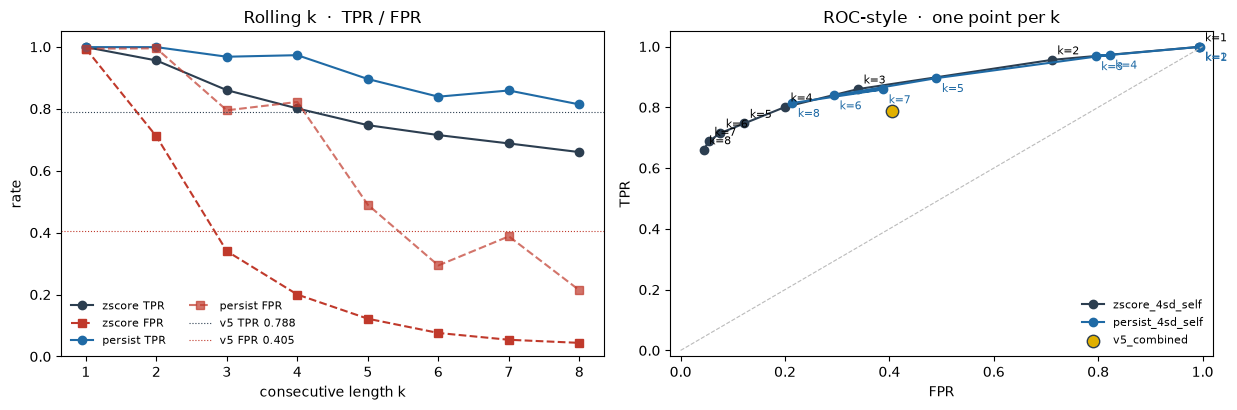

best Youden: zscore_4sd_self  k=6.0  TPR=0.715  FPR=0.076  Youden=0.639
v5_combined:                 TPR=0.788  FPR=0.405  Youden=0.383


In [32]:
def detection_table(frame: pd.DataFrame) -> dict:
    y = frame["csv_status"].astype(str).eq("faulty").to_numpy()
    yhat = frame["alarm"].astype(int).eq(1).to_numpy()
    tp = int((y & yhat).sum())
    fn = int((y & ~yhat).sum())
    fp = int((~y & yhat).sum())
    tn = int((~y & ~yhat).sum())
    n_pos = tp + fn
    n_neg = fp + tn
    tpr = tp / n_pos if n_pos else np.nan
    fpr = fp / n_neg if n_neg else np.nan
    return {
        "runs": int(len(frame)),
        "n_faulty": int(n_pos),
        "n_normal": int(n_neg),
        "TPR": tpr,
        "FPR": fpr,
        "Youden": (tpr - fpr) if np.isfinite(tpr) and np.isfinite(fpr) else np.nan,
        "TP": tp,
        "FN": fn,
        "FP": fp,
        "TN": tn,
        "mean_yellow": float(frame["n_yellow"].mean()),
        "mean_red": float(frame["n_red"].mean()),
    }


def method_rates(frame: pd.DataFrame) -> pd.DataFrame:
    rows = []
    v5 = frame.loc[frame["method"].eq("v5_combined")]
    rec = detection_table(v5)
    rec.update(method="v5_combined", k=np.nan)
    rows.append(rec)
    for name in ("zscore_4sd_self", "persist_4sd_self"):
        block = frame.loc[frame["method"].eq(name)]
        for k, g in block.groupby("k", sort=True):
            rec = detection_table(g)
            rec.update(method=name, k=int(k))
            rows.append(rec)
    out = pd.DataFrame(rows)
    return out[["method", "k", "runs", "n_faulty", "n_normal", "TPR", "FPR", "Youden", "TP", "FN", "FP", "TN", "mean_yellow", "mean_red"]]


rates = method_rates(alarms)
rates.to_csv(RATES_CACHE, index=False)
print("pred = any yellow or red sample   label = csv_status")
print("df1 = 1000 normal   df2 = 1000 faulty (50 per IDV)")
display(
    rates.style.format(
        {
            "k": "{:.0f}",
            "TPR": "{:.3f}",
            "FPR": "{:.3f}",
            "Youden": "{:.3f}",
            "mean_yellow": "{:.1f}",
            "mean_red": "{:.1f}",
            "runs": "{:.0f}",
            "n_faulty": "{:.0f}",
            "n_normal": "{:.0f}",
            "TP": "{:.0f}",
            "FN": "{:.0f}",
            "FP": "{:.0f}",
            "TN": "{:.0f}",
        },
        na_rep="—",
    )
)

# FPR split: train-normal vs test-normal, for the main three settings.
main = [
    ("v5_combined", np.nan),
    ("zscore_4sd_self", 1),
    ("zscore_4sd_self", 2),
    ("persist_4sd_self", 1),
    ("persist_4sd_self", 3),
    ("persist_4sd_self", 5),
]
split_rows = []
for name, k in main:
    if name == "v5_combined":
        block = alarms.loc[alarms["method"].eq(name)]
    else:
        block = alarms.loc[alarms["method"].eq(name) & alarms["k"].eq(k)]
    for src, g in block.groupby("source", observed=True, sort=True):
        rec = detection_table(g)
        rec.update(method=name, k=k, source=src)
        split_rows.append(rec)
split = pd.DataFrame(split_rows)
print("\nTrain vs test (same decision rule)")
display(
    split[["method", "k", "source", "runs", "n_faulty", "n_normal", "TPR", "FPR", "Youden", "TP", "FN", "FP", "TN"]].style.format(
        {"k": "{:.0f}", "TPR": "{:.3f}", "FPR": "{:.3f}", "Youden": "{:.3f}", "runs": "{:.0f}", "n_faulty": "{:.0f}", "n_normal": "{:.0f}", "TP": "{:.0f}", "FN": "{:.0f}", "FP": "{:.0f}", "TN": "{:.0f}"},
        na_rep="—",
    )
)

# Per-IDV TPR for v5 and a couple of rolling settings.
idv_methods = [
    ("v5_combined", np.nan, "v5_combined"),
    ("zscore_4sd_self", 2, "zscore k=2"),
    ("persist_4sd_self", 3, "persist k=3"),
]
idv_rows = []
for name, k, label in idv_methods:
    block = alarms.loc[alarms["method"].eq(name)] if name == "v5_combined" else alarms.loc[alarms["method"].eq(name) & alarms["k"].eq(k)]
    for idv, g in block.groupby("IDV", sort=True):
        faulty = g["csv_status"].astype(str).eq("faulty")
        idv_rows.append(
            {
                "method": label,
                "IDV": int(idv),
                "runs": len(g),
                "TPR": float(g.loc[faulty, "alarm"].mean()) if faulty.any() else np.nan,
                "FPR": float(g.loc[~faulty, "alarm"].mean()) if (~faulty).any() else np.nan,
            }
        )
by_idv = pd.DataFrame(idv_rows)
print("\nPer IDV  (IDV 0 = FPR on 1,000 normal runs; IDV 1–20 = TPR on 50 runs each)")
idv_wide = by_idv.pivot(index="IDV", columns="method", values=["TPR", "FPR"])
display(idv_wide.style.format("{:.3f}", na_rep="—"))

z_rates = rates.loc[rates["method"].eq("zscore_4sd_self")].sort_values("k")
p_rates = rates.loc[rates["method"].eq("persist_4sd_self")].sort_values("k")
v5 = rates.loc[rates["method"].eq("v5_combined")].iloc[0]

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.2))
ax = axes[0]
ax.plot(z_rates["k"], z_rates["TPR"], "o-", color="#2C3E50", label="zscore TPR")
ax.plot(z_rates["k"], z_rates["FPR"], "s--", color=RED, label="zscore FPR")
ax.plot(p_rates["k"], p_rates["TPR"], "o-", color="#1F6AA5", label="persist TPR")
ax.plot(p_rates["k"], p_rates["FPR"], "s--", color="#C0392B", alpha=0.7, label="persist FPR")
ax.axhline(v5["TPR"], color="#2C3E50", lw=0.8, ls=":", label=f"v5 TPR {v5['TPR']:.3f}")
ax.axhline(v5["FPR"], color=RED, lw=0.8, ls=":", label=f"v5 FPR {v5['FPR']:.3f}")
ax.set_xlabel("consecutive length k")
ax.set_ylabel("rate")
ax.set_ylim(0, 1.05)
ax.set_title("Rolling k  ·  TPR / FPR")
ax.legend(frameon=False, fontsize=8, ncol=2)

ax = axes[1]
ax.plot(z_rates["FPR"], z_rates["TPR"], "o-", color="#2C3E50", label="zscore_4sd_self")
for _, r in z_rates.iterrows():
    ax.annotate(f"k={int(r['k'])}", (r["FPR"], r["TPR"]), textcoords="offset points", xytext=(4, 4), fontsize=8)
ax.plot(p_rates["FPR"], p_rates["TPR"], "o-", color="#1F6AA5", label="persist_4sd_self")
for _, r in p_rates.iterrows():
    ax.annotate(f"k={int(r['k'])}", (r["FPR"], r["TPR"]), textcoords="offset points", xytext=(4, -10), fontsize=8, color="#1F6AA5")
ax.scatter([v5["FPR"]], [v5["TPR"]], s=80, color=YELLOW, edgecolor="#2C3E50", zorder=5, label="v5_combined")
ax.plot([0, 1], [0, 1], color="#bbb", lw=0.8, ls="--")
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_xlim(-0.02, 1.02)
ax.set_ylim(-0.02, 1.05)
ax.set_title("ROC-style  ·  one point per k")
ax.legend(frameon=False, fontsize=8)
fig.tight_layout()
plt.show()

best = rates.sort_values("Youden", ascending=False).iloc[0]
print(
    f"best Youden: {best['method']}  k={best['k']}  TPR={best['TPR']:.3f}  FPR={best['FPR']:.3f}  Youden={best['Youden']:.3f}"
)
print(f"v5_combined:                 TPR={v5['TPR']:.3f}  FPR={v5['FPR']:.3f}  Youden={v5['Youden']:.3f}")


## 5. Out-of-range, correlation, and unions with zscore k=6

Same 2,000 runs, same call (any yellow/red → faulty), still **this run only**, one tick at a time.

Frozen 20-sample boxes and a noisy top-20 correlation score both stayed red for hundreds of ticks (TPR=FPR=1). This cell **regulates** that.

| method | at sample `t` |
| --- | --- |
| **`zscore_k6`** | expanding `z_t=(x_t−μ_{t−1})/σ_{t−1}`; last 6 ticks all have some `\|z\|≥4` |
| **`out_of_range`** | rolling **50-sample** min/max (past only), padded by 25% of that range. **Same sensor** must sit outside for **3** ticks (yellow) / **5** (red). One outlier never alerts |
| **`corr`** | expanding `xmeas` `R_t` vs **R₀ from samples 1–80**. Score = **p90** `\|Δρ\|`, and the **median** `\|Δρ\|` must also clear a floor (not a handful of noisy pairs). **8** consecutive ticks. Yellow 0.45 / 0.15, red 0.62 / 0.25 |
| **unions** | sample-wise `max(level)` (true OR), then the same run-level call |

`zscore_k6` is recomputed here (numpy, not the §3 cache) so unions cannot desync. Delete `v6_eval_oor_corr_v3.csv` to rescore.


/var/folders/hw/zh08vgx16815gz89lgw4z6qw0000gn/T/ipykernel_1251/169694258.py:35: RuntimeWarning: All-NaN slice encountered
  zmax = np.nanmax(np.abs(z), axis=1)
19:48:38  INFO     oor/corr    1 / 2000  0.2s
19:48:40  INFO     oor/corr    50 / 2000  2.9s
19:48:43  INFO     oor/corr    100 / 2000  5.2s
19:48:45  INFO     oor/corr    150 / 2000  7.6s
19:48:47  INFO     oor/corr    200 / 2000  9.8s
19:48:50  INFO     oor/corr    250 / 2000  12.1s
19:48:52  INFO     oor/corr    300 / 2000  14.4s
19:48:54  INFO     oor/corr    350 / 2000  16.7s
19:48:57  INFO     oor/corr    400 / 2000  19.0s
19:48:59  INFO     oor/corr    450 / 2000  21.5s
19:49:01  INFO     oor/corr    500 / 2000  23.7s
19:49:04  INFO     oor/corr    550 / 2000  26.1s
19:49:06  INFO     oor/corr    600 / 2000  28.4s
19:49:08  INFO     oor/corr    650 / 2000  30.7s
19:49:10  INFO     oor/corr    700 / 2000  32.9s
19:49:13  INFO     oor/corr    750 / 2000  35.3s
19:49:15  INFO     oor/corr    800 / 2000  37.4s
19:49:17  INFO

Same 2,000 runs. Unions = sample-wise OR. Delete v6_eval_oor_corr_v3.csv to rescore.
out_of_range = rolling 50 min/max + 25% pad; same sensor 3/5 consecutive (one tick never alerts).
corr = p90 |Δρ| vs R₀ (n=80) AND median |Δρ| floor; 8 consecutive. Sceptical.


,runs,n_faulty,n_normal,TPR,FPR,Youden,TP,FN,FP,TN,mean_yellow,mean_red,vs_zscore_k6
method,,,,,,,,,,,,,
zscore_k6,2000,1000,1000,0.715,0.076,0.639,715,285,76,924,20.9,1.6,+0.000
out_of_range,2000,1000,1000,0.218,0.001,0.217,218,782,1,999,0.2,0.0,-0.422
corr,2000,1000,1000,0.447,0.000,0.447,447,553,0,1000,89.3,60.3,-0.192
zscore_k6 ∪ oor,2000,1000,1000,0.724,0.077,0.647,724,276,77,923,21.0,1.6,+0.008
zscore_k6 ∪ corr,2000,1000,1000,0.716,0.076,0.640,716,284,76,924,97.2,61.4,+0.001
oor ∪ corr,2000,1000,1000,0.540,0.001,0.539,540,460,1,999,89.5,60.3,-0.100
zscore_k6 ∪ oor ∪ corr,2000,1000,1000,0.725,0.077,0.648,725,275,77,923,97.3,61.4,+0.009


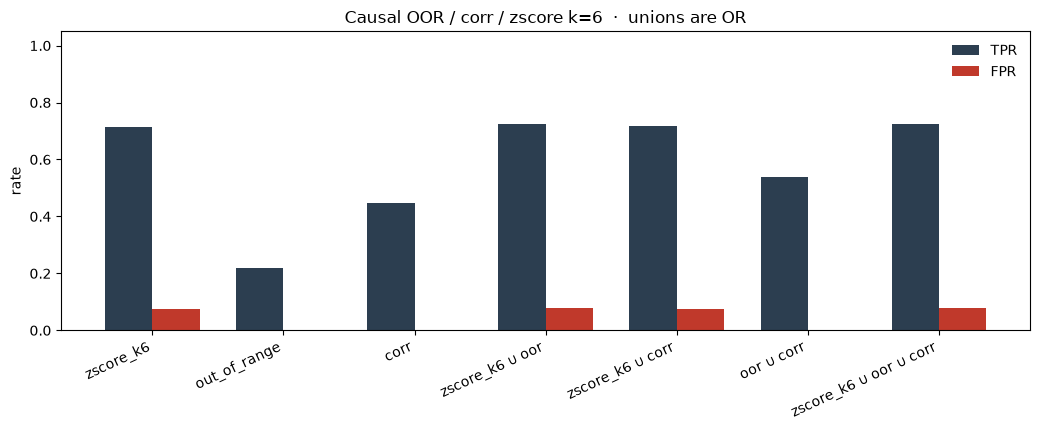

best Youden: zscore_k6 ∪ oor ∪ corr  TPR=0.725  FPR=0.077  Youden=0.648
zscore_k6:    TPR=0.715  FPR=0.076  Youden=0.639


In [33]:
COMBO_CACHE = Path("v6_eval_oor_corr_v3.csv")
ZSCORE_K = 6
OOR_W = 50
OOR_PAD = 0.25
OOR_K_Y, OOR_K_R = 3, 5
CORR_REF = 80
CORR_K = 8
CORR_Y, CORR_R = 0.45, 0.62
CORR_MED_Y, CORR_MED_R = 0.15, 0.25


def _finite_X(X: np.ndarray) -> np.ndarray:
    out = np.asarray(X, dtype=np.float64).copy()
    col = np.nanmedian(out[:BURNIN], axis=0)
    col = np.where(np.isfinite(col), col, 0.0)
    bad = ~np.isfinite(out)
    if bad.any():
        out[bad] = np.take(col, np.where(bad)[1])
    return out


def zscore_k6_level(X: np.ndarray) -> np.ndarray:
    X = np.asarray(X, dtype=np.float64)
    T = X.shape[0]
    n = np.arange(1, T + 1, dtype=np.float64)[:, None]
    csum = np.cumsum(X, axis=0)
    mean = csum / n
    var = np.maximum(np.cumsum(X * X, axis=0) - mean * csum, 0.0) / np.maximum(n - 1.0, 1.0)
    sd = np.sqrt(var)
    sd[0] = np.nan
    z = np.full_like(X, np.nan)
    floor = np.maximum(1e-6 * np.abs(mean[:-1]), 1e-8)
    with np.errstate(invalid="ignore", divide="ignore"):
        z[1:] = (X[1:] - mean[:-1]) / np.maximum(sd[:-1], floor)
    zmax = np.nanmax(np.abs(z), axis=1)
    z4 = np.isfinite(zmax) & (zmax >= 4.0)
    z6 = np.isfinite(zmax) & (zmax >= 6.0)
    z4[:BURNIN] = False
    z6[:BURNIN] = False
    return level_from_streaks(consecutive_streak(z4), consecutive_streak(z6), ZSCORE_K, ZSCORE_K)


def consecutive_streak_cols(hits: np.ndarray) -> np.ndarray:
    """Per-column run length. A single True never reaches k=2."""
    h = np.asarray(hits, dtype=bool)
    T, S = h.shape
    out = np.zeros((T, S), dtype=np.int16)
    for t in range(T):
        if t == 0:
            out[0] = h[0]
        else:
            out[t] = np.where(h[t], out[t - 1] + 1, 0)
    return out


def _rolling_past_minmax(X: np.ndarray, w: int) -> tuple[np.ndarray, np.ndarray]:
    """Min/max of X[t-w:t] (current sample not in the window)."""
    T, S = X.shape
    lo = np.full((T, S), np.nan)
    hi = np.full((T, S), np.nan)
    if T <= w:
        return lo, hi
    frame = pd.DataFrame(X)
    rmin = frame.rolling(w, min_periods=w).min().to_numpy(np.float64)
    rmax = frame.rolling(w, min_periods=w).max().to_numpy(np.float64)
    lo[w:] = rmin[w - 1 : -1]
    hi[w:] = rmax[w - 1 : -1]
    return lo, hi


def oor_level(X: np.ndarray) -> np.ndarray:
    """Rolling 50 min/max + 25% pad. Same sensor must leave the box for 3/5 ticks."""
    X = np.asarray(X, dtype=np.float64)
    lo, hi = _rolling_past_minmax(X, OOR_W)
    span = np.maximum(hi - lo, 1e-12)
    pad = OOR_PAD * span
    outside = (X < (lo - pad)) | (X > (hi + pad))
    outside[:OOR_W] = False
    outside[~np.isfinite(X)] = False
    streak = consecutive_streak_cols(outside).max(axis=1)
    return level_from_streaks(streak, streak, OOR_K_Y, OOR_K_R)


def corr_change_score(X_meas: np.ndarray) -> tuple[np.ndarray, np.ndarray]:
    """p90 and median |ρ_t − ρ₀| vs frozen R₀ from samples 1..CORR_REF."""
    X = _finite_X(X_meas)
    T, S = X.shape
    p90 = np.full(T, np.nan)
    p50 = np.full(T, np.nan)
    acc = np.zeros((S, S), dtype=np.float64)
    csum = np.zeros(S, dtype=np.float64)
    R0 = None
    triu = np.triu_indices(S, 1)
    for t in range(T):
        xt = X[t]
        acc += np.outer(xt, xt)
        csum += xt
        n = t + 1
        if n < 8:
            continue
        mean = csum / n
        cov = acc / n - np.outer(mean, mean)
        d = np.sqrt(np.clip(np.diag(cov), 1e-18, None))
        R = np.clip(cov / np.outer(d, d), -1.0, 1.0)
        np.fill_diagonal(R, 1.0)
        if n == CORR_REF:
            R0 = R.copy()
        if R0 is not None and n > CORR_REF:
            dlt = np.abs(R[triu] - R0[triu])
            p90[t] = float(np.quantile(dlt, 0.90))
            p50[t] = float(np.median(dlt))
    return p90, p50


def corr_level(p90: np.ndarray, p50: np.ndarray) -> np.ndarray:
    y = np.isfinite(p90) & (p90 >= CORR_Y) & np.isfinite(p50) & (p50 >= CORR_MED_Y)
    r = np.isfinite(p90) & (p90 >= CORR_R) & np.isfinite(p50) & (p50 >= CORR_MED_R)
    y[:CORR_REF] = False
    r[:CORR_REF] = False
    return level_from_streaks(consecutive_streak(y), consecutive_streak(r), CORR_K, CORR_K)


def load_or_score_oor_corr() -> pd.DataFrame:
    if COMBO_CACHE.exists():
        out = pd.read_csv(COMBO_CACHE)
        need = {"out_of_range", "corr", "zscore_k6", "zscore_k6 ∪ oor"}
        if need.issubset(set(out["method"])):
            log.info("cache hit   %s  rows=%s", COMBO_CACHE.name, f"{len(out):,}")
            return out
        log.info("cache miss  methods changed — rescoring")

    rows: list[dict] = []
    runs = pd.concat([df1, df2], ignore_index=True)
    groups = runs.groupby(["source", "faultNumber", "simulationRun"], sort=True, observed=True)
    n_groups = groups.ngroups
    t0 = time.time()
    for i, (_, g) in enumerate(groups, start=1):
        g = g.sort_values("sample")
        X = g[SENSOR_COLS].to_numpy(np.float64)
        X_meas = g[MEAS_COLS].to_numpy(np.float64)
        src = str(g["source"].iloc[0])
        fn = int(g["faultNumber"].iloc[0])
        rn = int(g["simulationRun"].iloc[0])
        status = str(g["fault_status"].iloc[0])
        z_lv = zscore_k6_level(X)
        o_lv = oor_level(X)
        c_lv = corr_level(*corr_change_score(X_meas))
        zo = np.maximum(z_lv, o_lv)
        zc = np.maximum(z_lv, c_lv)
        oc = np.maximum(o_lv, c_lv)
        zoc = np.maximum(zo, c_lv)
        for name, lv in (
            ("zscore_k6", z_lv),
            ("out_of_range", o_lv),
            ("corr", c_lv),
            ("zscore_k6 ∪ oor", zo),
            ("zscore_k6 ∪ corr", zc),
            ("oor ∪ corr", oc),
            ("zscore_k6 ∪ oor ∪ corr", zoc),
        ):
            rows.append(summarize_level(lv, method=name, k=np.nan, src=src, fn=fn, rn=rn, status=status))
        if i == 1 or i % 50 == 0 or i == n_groups:
            log.info("oor/corr    %s / %s  %.1fs", i, n_groups, time.time() - t0)
    out = pd.DataFrame(rows)
    out.to_csv(COMBO_CACHE, index=False)
    log.info("cache write %s  rows=%s", COMBO_CACHE.name, f"{len(out):,}")
    return out


combo = load_or_score_oor_corr()
order = [
    "zscore_k6",
    "out_of_range",
    "corr",
    "zscore_k6 ∪ oor",
    "zscore_k6 ∪ corr",
    "oor ∪ corr",
    "zscore_k6 ∪ oor ∪ corr",
]
combo_rows = []
for name in order:
    block = combo.loc[combo["method"].eq(name)]
    rec = detection_table(block)
    rec["method"] = name
    combo_rows.append(rec)
combo_rates = pd.DataFrame(combo_rows).set_index("method")
z6_youden = float(combo_rates.loc["zscore_k6", "Youden"])
combo_rates["vs_zscore_k6"] = combo_rates["Youden"] - z6_youden
print("Same 2,000 runs. Unions = sample-wise OR. Delete v6_eval_oor_corr_v3.csv to rescore.")
print("out_of_range = rolling 50 min/max + 25% pad; same sensor 3/5 consecutive (one tick never alerts).")
print("corr = p90 |Δρ| vs R₀ (n=80) AND median |Δρ| floor; 8 consecutive. Sceptical.")
display(
    combo_rates.style.format(
        {
            "TPR": "{:.3f}",
            "FPR": "{:.3f}",
            "Youden": "{:.3f}",
            "vs_zscore_k6": "{:+.3f}",
            "runs": "{:.0f}",
            "n_faulty": "{:.0f}",
            "n_normal": "{:.0f}",
            "TP": "{:.0f}",
            "FN": "{:.0f}",
            "FP": "{:.0f}",
            "TN": "{:.0f}",
            "mean_yellow": "{:.1f}",
            "mean_red": "{:.1f}",
        }
    )
)

fig, ax = plt.subplots(figsize=(10.5, 4.4))
x = np.arange(len(combo_rates))
w = 0.36
ax.bar(x - w / 2, combo_rates["TPR"].to_numpy(), w, color="#2C3E50", label="TPR")
ax.bar(x + w / 2, combo_rates["FPR"].to_numpy(), w, color=RED, label="FPR")
ax.set_xticks(x, combo_rates.index, rotation=25, ha="right")
ax.set_ylim(0, 1.05)
ax.set_ylabel("rate")
ax.set_title("Causal OOR / corr / zscore k=6  ·  unions are OR")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

best = combo_rates["Youden"].idxmax()
print(
    f"best Youden: {best}  TPR={combo_rates.loc[best, 'TPR']:.3f}  "
    f"FPR={combo_rates.loc[best, 'FPR']:.3f}  Youden={combo_rates.loc[best, 'Youden']:.3f}"
)
print(
    f"zscore_k6:    TPR={combo_rates.loc['zscore_k6', 'TPR']:.3f}  "
    f"FPR={combo_rates.loc['zscore_k6', 'FPR']:.3f}  Youden={combo_rates.loc['zscore_k6', 'Youden']:.3f}"
)
